In [1]:
# Step 1: Import Necessary Libraries
import os
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt
from nilearn import image, plotting, masking, datasets
from nilearn.input_data import NiftiMasker
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
import seaborn as sns
import keras
from keras.models import Sequential
from keras.layers import Dense

In [2]:
import os

def get_bold_file_paths(base_dir):
    control_subjects = []
    non_dyslexic_subjects = []
    control_ids = {11, 12, 13, 18, 19, 23, 24, 25, 26, 29, 30, 31, 32, 33, 34, 35, 36, 37, 40, 41}
    
    for sub_num in range(1, 43):  # Looping from sub-01 to sub-42
        sub_folder = f"sub-{sub_num:02d}"  # Format to ensure two-digit numbering
        #func_path = os.path.join(base_dir, sub_folder, "func")
        func_path = os.path.join(base_dir, sub_folder)
        
        if os.path.exists(func_path):
            for file in os.listdir(func_path):
                if file.endswith(("task-morphosem_run-01_bold.nii.gz","task-morphosem_run-02_bold.nii.gz","task-morphosem_run-03_bold.nii.gz","task-morphosem_run-04_bold.nii.gz")):
                    file_path = os.path.join(func_path, file)
                    if sub_num in control_ids:
                        control_subjects.append(file_path)
                    else:
                        non_dyslexic_subjects.append(file_path)
    
    return control_subjects, non_dyslexic_subjects

# Set the base directory
#base_directory = r"D:\project_7th_sem\ds004786-download"
base_directory = r"D:\myResearch\Dataset01_MorphoSem"

# Get the list of file paths
control_subjects, non_dyslexic_subjects = get_bold_file_paths(base_directory)

# Print the lists
print("Control Subjects:")
for i,path in enumerate(control_subjects):
    print(path)

print("\nNon-Dyslexic Subjects:")
for j,path in enumerate(non_dyslexic_subjects):
    print(path)

print (i)
print (j)

print(len(control_subjects),len(non_dyslexic_subjects))

Control Subjects:
D:\myResearch\Dataset01_MorphoSem\sub-11\sub-11_task-morphosem_run-01_bold.nii.gz
D:\myResearch\Dataset01_MorphoSem\sub-11\sub-11_task-morphosem_run-02_bold.nii.gz
D:\myResearch\Dataset01_MorphoSem\sub-11\sub-11_task-morphosem_run-03_bold.nii.gz
D:\myResearch\Dataset01_MorphoSem\sub-11\sub-11_task-morphosem_run-04_bold.nii.gz
D:\myResearch\Dataset01_MorphoSem\sub-12\sub-12_task-morphosem_run-01_bold.nii.gz
D:\myResearch\Dataset01_MorphoSem\sub-12\sub-12_task-morphosem_run-02_bold.nii.gz
D:\myResearch\Dataset01_MorphoSem\sub-12\sub-12_task-morphosem_run-03_bold.nii.gz
D:\myResearch\Dataset01_MorphoSem\sub-12\sub-12_task-morphosem_run-04_bold.nii.gz
D:\myResearch\Dataset01_MorphoSem\sub-13\sub-13_task-morphosem_run-01_bold.nii.gz
D:\myResearch\Dataset01_MorphoSem\sub-13\sub-13_task-morphosem_run-02_bold.nii.gz
D:\myResearch\Dataset01_MorphoSem\sub-13\sub-13_task-morphosem_run-03_bold.nii.gz
D:\myResearch\Dataset01_MorphoSem\sub-13\sub-13_task-morphosem_run-04_bold.nii.g

[get_dataset_dir] Dataset found in C:\Users\utpal\nilearn_data\fsl

0: Background
1: Frontal Pole
2: Insular Cortex
3: Superior Frontal Gyrus
4: Middle Frontal Gyrus
5: Inferior Frontal Gyrus, pars triangularis
6: Inferior Frontal Gyrus, pars opercularis
7: Precentral Gyrus
8: Temporal Pole
9: Superior Temporal Gyrus, anterior division
10: Superior Temporal Gyrus, posterior division
11: Middle Temporal Gyrus, anterior division
12: Middle Temporal Gyrus, posterior division
13: Middle Temporal Gyrus, temporooccipital part
14: Inferior Temporal Gyrus, anterior division
15: Inferior Temporal Gyrus, posterior division
16: Inferior Temporal Gyrus, temporooccipital part
17: Postcentral Gyrus
18: Superior Parietal Lobule
19: Supramarginal Gyrus, anterior division
20: Supramarginal Gyrus, posterior division
21: Angular Gyrus
22: Lateral Occipital Cortex, superior division
23: Lateral Occipital Cortex, inferior division
24: Intracalcarine Cortex
25: Frontal Medial Cortex
26: Juxtapositional Lobule Cortex (formerly Supplementary Motor Cortex)
27: Subcallosal Cort

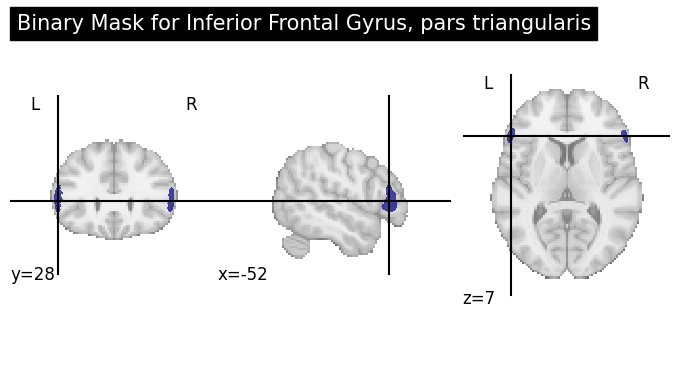

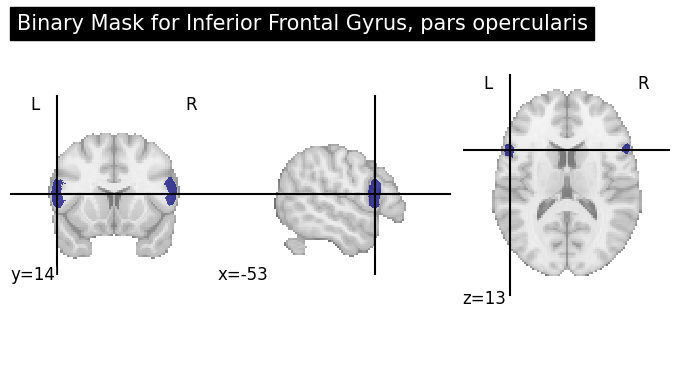

In [3]:
# Step 2: Load the Harvard-Oxford atlas and select a specific region
from nilearn.image import math_img

# Load the Harvard-Oxford cortical atlas (probabilistic map)
atlas = datasets.fetch_atlas_harvard_oxford('cort-maxprob-thr50-1mm')
atlas_img = atlas['maps']
atlas_labels = atlas['labels']

# Print available region labels to confirm the correct region index
for idx, label in enumerate(atlas_labels):
    print(f"{idx}: {label}")

# Select the index for the desired region (e.g., Inferior Frontal Gyrus, pars triangularis)
region_name1 = "Inferior Frontal Gyrus, pars triangularis"  # Region of Interest
region_idx1 = atlas_labels.index(region_name1)  # Find index for Inferior Frontal Gyrus, pars triangularis

# Create a binary mask for the selected region
binary_mask1 = math_img(f"img == {region_idx1}", img=atlas_img)

# Visualize the binary mask to ensure it's correctly created
plotting.plot_roi(binary_mask1, title=f"Binary Mask for {region_name1}", display_mode='ortho')
plotting.show()

# Select the index for the desired region (e.g., Inferior Frontal Gyrus, pars opercularis)
region_name2 = "Inferior Frontal Gyrus, pars opercularis"  # Region of Interest
region_idx2 = atlas_labels.index(region_name2)  # Find index for Inferior Frontal Gyrus, pars opercularis 
# Create a binary mask for the selected region
binary_mask2 = math_img(f"img == {region_idx2}", img=atlas_img)
# Visualize the binary mask to ensure it's correctly created
plotting.plot_roi(binary_mask2, title=f"Binary Mask for {region_name2}", display_mode='ortho')
plotting.show()

## Extracting all the ROIs **(WITHOUT MEAN)**

In [4]:
# Initialize NiftiMasker
roi_masker1 = NiftiMasker(mask_img=binary_mask1, standardize=True)

# Aggregate data across time for each control subject
control_data1 = [roi_masker1.fit_transform(nib.load(subject)) for subject in control_subjects]

# Aggregate data across time for each non-dyslexic subject
non_dyslexic_data1 = [roi_masker1.fit_transform(nib.load(subject)) for subject in non_dyslexic_subjects]

# Initialize NiftiMasker
roi_masker2 = NiftiMasker(mask_img=binary_mask2, standardize=True)

# Aggregate data across time for each control subject
control_data2 = [roi_masker2.fit_transform(nib.load(subject)) for subject in control_subjects]

# Aggregate data across time for each non-dyslexic subject
non_dyslexic_data2 = [roi_masker2.fit_transform(nib.load(subject)) for subject in non_dyslexic_subjects]

D:\Aanaconda3\envs\env_sih\lib\site-packages\nilearn\maskers\nifti_masker.py:114: UserWarning: imgs are being resampled to the mask_img resolution. This process is memory intensive. You might want to provide a target_affine that is equal to the affine of the imgs or resample the mask beforehand to save memory and computation time.
  warnings.warn(


[NiftiMasker.wrapped] Resampling images

D:\Aanaconda3\envs\env_sih\lib\site-packages\joblib\memory.py:312: UserWarning: Casting data from int16 to float32
  return self.func(*args, **kwargs)
D:\Aanaconda3\envs\env_sih\lib\site-packages\nilearn\maskers\nifti_masker.py:114: UserWarning: imgs are being resampled to the mask_img resolution. This process is memory intensive. You might want to provide a target_affine that is equal to the affine of the imgs or resample the mask beforehand to save memory and computation time.
  warnings.warn(


[NiftiMasker.wrapped] Resampling images

D:\Aanaconda3\envs\env_sih\lib\site-packages\joblib\memory.py:312: UserWarning: Casting data from int16 to float32
  return self.func(*args, **kwargs)
D:\Aanaconda3\envs\env_sih\lib\site-packages\nilearn\maskers\nifti_masker.py:114: UserWarning: imgs are being resampled to the mask_img resolution. This process is memory intensive. You might want to provide a target_affine that is equal to the affine of the imgs or resample the mask beforehand to save memory and computation time.
  warnings.warn(


...

[NiftiMasker.wrapped] Resampling images

D:\Aanaconda3\envs\env_sih\lib\site-packages\joblib\memory.py:312: UserWarning: Casting data from int16 to float32
  return self.func(*args, **kwargs)
D:\Aanaconda3\envs\env_sih\lib\site-packages\nilearn\maskers\nifti_masker.py:114: UserWarning: imgs are being resampled to the mask_img resolution. This process is memory intensive. You might want to provide a target_affine that is equal to the affine of the imgs or resample the mask beforehand to save memory and computation time.
  warnings.warn(


[NiftiMasker.wrapped] Resampling images

D:\Aanaconda3\envs\env_sih\lib\site-packages\joblib\memory.py:312: UserWarning: Casting data from int16 to float32
  return self.func(*args, **kwargs)
D:\Aanaconda3\envs\env_sih\lib\site-packages\nilearn\maskers\nifti_masker.py:114: UserWarning: imgs are being resampled to the mask_img resolution. This process is memory intensive. You might want to provide a target_affine that is equal to the affine of the imgs or resample the mask beforehand to save memory and computation time.
  warnings.warn(


[NiftiMasker.wrapped] Resampling images

## Saving all the ROIs **[Without Mean]**

##### To save the ROIs we have to make sure that all the data are of the same dimensions else it won't save on Disk.

##### <b>Checking the dimensions for control_data1 and saving on Disk</b>

In [5]:
row,col=control_data1[0].shape
#print("control_data1",row,col)
cd1=[]
#Checking if there is uneven dimensions
for i in range(len(control_data1)):
    r,c=control_data1[i].shape
    if (r!=row or c!=col):
        print("control_data1",i,r,c,"<<--HERE")
        cd1.append(i)
#If there is uneven dimensions, then correcting the dimensions
if(len(cd1)!=0):
    print("control_data1 -< Problem in index no >--",cd1)
    row,col=control_data1[0].shape
    control1=[]
    for i in range(len(control_data1)):
        r,c=control_data1[i].shape
        if (row>r): ##Correcting the row dimension
            add1=np.mean(control_data1[i], axis = 0)
            add1=add1.reshape(1,add1.shape[0])
            #temp=np.empty((0, row*col), np.float32)
            temp=control_data1[i]
            for j in range(row-r):
                temp=np.append(temp, add1, axis=0)
            control1.append(temp)
        elif (col>c): ##Correcting the column dimension
            temp=np.empty((0, row*col), np.float32)
            for j in range(control_data1[0].shape[0]):
                add1=np.pad(control_data1[i][j], (0, col-c), 'mean')
                temp=np.append(temp, add1, axis=0)
            control1.append(temp)
        else:
            control1.append(control_data1[i])

if(len(cd1)!=0):
    print("control_data1",len(control_data1))
    print("control1",len(control1))
    print("Before")
    for i in range(len(cd1)):
        print("At Index",cd1[i],control_data1[cd1[i]].shape)
    print("After")
    for i in range(len(cd1)):
        print("At Index",cd1[i],control1[cd1[i]].shape)
    np.savez("../../Data_Mask-ROI/1-Inferior_Frontal_Gyrus/control_pars_triangularis.npz", control_data1=control1)
    print("Corrected data is saved on Disk as np file")
else:
    print("No corrections required, all dimensions are same")
    np.savez("../../Data_Mask-ROI/1-Inferior_Frontal_Gyrus/control_pars_triangularis.npz", control_data1=control_data1)
    print("Data is saved on Disk as np file")

control_data1 23 256 2377 <<--HERE
control_data1 -< Problem in index no >-- [23]
control_data1 80
control1 80
Before
At Index 23 (256, 2377)
After
At Index 23 (274, 2377)
Corrected data is saved on Disk as np file


##### <b>Checking the dimensions for non_dyslexic_data1 and saving on Disk</b>

In [6]:
row,col=non_dyslexic_data1[0].shape
#print("non_dyslexic_data1",row,col)
cd1=[]
#Checking if there is uneven dimensions
for i in range(len(non_dyslexic_data1)):
    r,c=non_dyslexic_data1[i].shape
    if (r!=row or c!=col):
        print("non_dyslexic_data1",i,r,c,"<<--HERE")
        cd1.append(i)
#If there is uneven dimensions, then correcting the dimensions
if(len(cd1)!=0):
    print("non_dyslexic_data1 -< Problem in index no >--",cd1)
    row,col=non_dyslexic_data1[0].shape
    non_dyslexic1=[]
    for i in range(len(non_dyslexic_data1)):
        r,c=non_dyslexic_data1[i].shape
        if (row>r): ##Correcting the row dimension
            add1=np.mean(non_dyslexic_data1[i], axis = 0)
            add1=add1.reshape(1,add1.shape[0])
            #temp=np.empty((0, row*col), np.float32)
            temp=non_dyslexic_data1[i]
            for j in range(row-r):
                temp=np.append(temp, add1, axis=0)
            non_dyslexic1.append(temp)
        elif (col>c): ##Correcting the column dimension
            temp=np.empty((0, row*col), np.float32)
            for j in range(non_dyslexic_data1[0].shape[0]):
                add1=np.pad(non_dyslexic_data1[i][j], (0, col-c), 'mean')
                temp=np.append(temp, add1, axis=0)
            non_dyslexic1.append(temp)
        else:
            non_dyslexic1.append(non_dyslexic_data1[i])

if(len(cd1)!=0):
    print("non_dyslexic_data1",len(non_dyslexic_data1))
    print("non_dyslexic1",len(non_dyslexic1))
    print("Before")
    for i in range(len(cd1)):
        print("At Index",cd1[i],non_dyslexic_data1[cd1[i]].shape)
    print("After")
    for i in range(len(cd1)):
        print("At Index",cd1[i],non_dyslexic1[cd1[i]].shape)
    np.savez("../../Data_Mask-ROI/1-Inferior_Frontal_Gyrus/non_dyslexic_pars_triangularis.npz", non_dyslexic_data1=non_dyslexic1)
    print("Corrected data is saved on Disk as np file")
else:
    print("No corrections required, all dimensions are same")
    np.savez("../../Data_Mask-ROI/1-Inferior_Frontal_Gyrus/non_dyslexic_pars_triangularis.npz", non_dyslexic_data1=non_dyslexic_data1)
    print("Data is saved on Disk as np file")

No corrections required, all dimensions are same
Data is saved on Disk as np file


##### <b>Checking the dimensions for control_data2 and saving on Disk</b>

In [86]:
row,col=control_data2[0].shape
#print("control_data2",row,col)
cd1=[]
#Checking if there is uneven dimensions
for i in range(len(control_data2)):
    r,c=control_data2[i].shape
    if (r!=row or c!=col):
        print("control_data2",i,r,c,"<<--HERE")
        cd1.append(i)
#If there is uneven dimensions, then correcting the dimensions
if(len(cd1)!=0):
    print("control_data2 -< Problem in index no >--",cd1)
    row,col=control_data2[0].shape
    control2=[]
    for i in range(len(control_data2)):
        r,c=control_data2[i].shape
        if (row>r): ##Correcting the row dimension
            add1=np.mean(control_data2[i], axis = 0)
            add1=add1.reshape(1,add1.shape[0])
            #temp=np.empty((0, row*col), np.float32)
            temp=control_data2[i]
            for j in range(row-r):
                temp=np.append(temp, add1, axis=0)
            control2.append(temp)
        elif (col>c): ##Correcting the column dimension
            temp=np.empty((0, row*col), np.float32)
            for j in range(control_data2[0].shape[0]):
                add1=np.pad(control_data2[i][j], (0, col-c), 'mean')
                temp=np.append(temp, add1, axis=0)
            control2.append(temp)
        else:
            control2.append(control_data2[i])

if(len(cd1)!=0):
    print("control_data2",len(control_data2))
    print("control2",len(control2))
    print("Before")
    for i in range(len(cd1)):
        print("At Index",cd1[i],control_data2[cd1[i]].shape)
    print("After")
    for i in range(len(cd1)):
        print("At Index",cd1[i],control2[cd1[i]].shape)
    np.savez("../../Data_Mask-ROI/1-Inferior_Frontal_Gyrus/control_pars_opercularis.npz", control_data2=control2)
    print("Corrected data is saved on Disk as np file")
else:
    print("No corrections required, all dimensions are same")
    np.savez("../../Data_Mask-ROI/1-Inferior_Frontal_Gyrus/control_pars_opercularis.npz", control_data2=control_data2)
    print("Data is saved on Disk as np file")

control_data2 23 256 3846 <<--HERE
control_data2 -< Problem in index no >-- [23]
control_data2 80
control2 80
Before
At Index 23 (256, 3846)
After
At Index 23 (274, 3846)
Corrected data is saved on Disk as np file


##### <b>Checking the dimensions for non_dyslexic_data2 and saving on Disk</b>

In [95]:
row,col=non_dyslexic_data2[0].shape
#print("non_dyslexic_data2",row,col)
cd1=[]
#Checking if there is uneven dimensions
for i in range(len(non_dyslexic_data2)):
    r,c=non_dyslexic_data2[i].shape
    if (r!=row or c!=col):
        print("non_dyslexic_data2",i,r,c,"<<--HERE")
        cd1.append(i)
#If there is uneven dimensions, then correcting the dimensions
if(len(cd1)!=0):
    print("non_dyslexic_data2 -< Problem in index no >--",cd1)
    row,col=non_dyslexic_data2[0].shape
    non_dyslexic2=[]
    for i in range(len(non_dyslexic_data2)):
        r,c=non_dyslexic_data2[i].shape
        if (row>r): ##Correcting the row dimension
            add1=np.mean(non_dyslexic_data2[i], axis = 0)
            add1=add1.reshape(1,add1.shape[0])
            #temp=np.empty((0, row*col), np.float32)
            temp=non_dyslexic_data2[i]
            for j in range(row-r):
                temp=np.append(temp, add1, axis=0)
            non_dyslexic2.append(temp)
        elif (col>c): ##Correcting the column dimension
            temp=np.empty((0, row*col), np.float32)
            for j in range(non_dyslexic_data2[0].shape[0]):
                add1=np.pad(non_dyslexic_data2[i][j], (0, col-c), 'mean')
                temp=np.append(temp, add1, axis=0)
            non_dyslexic2.append(temp)
        else:
            non_dyslexic2.append(non_dyslexic_data2[i])

if(len(cd1)!=0):
    print("non_dyslexic_data2",len(non_dyslexic_data2))
    print("non_dyslexic2",len(non_dyslexic2))
    print("Before")
    for i in range(len(cd1)):
        print("At Index",cd1[i],non_dyslexic_data2[cd1[i]].shape)
    print("After")
    for i in range(len(cd1)):
        print("At Index",cd1[i],non_dyslexic2[cd1[i]].shape)
    np.savez("../../Data_Mask-ROI/1-Inferior_Frontal_Gyrus/non_dyslexic_pars_opercularis.npz", non_dyslexic_data2=non_dyslexic2)
    print("Corrected data is saved on Disk as np file")
else:
    print("No corrections required, all dimensions are same")
    np.savez("../../Data_Mask-ROI/1-Inferior_Frontal_Gyrus/non_dyslexic_pars_opercularis.npz", non_dyslexic_data2=non_dyslexic_data2)
    print("Data is saved on Disk as np file")

No corrections required, all dimensions are same
Data is saved on Disk as np file


## Till here all ROIs saved **[ Without MEAN ]**

#### Load all ROIs saved **[ Without MEAN ]**

In [2]:
####Loading all the saved dataset in np format.
cd1 = np.load("../../Data_Mask-ROI/1-Inferior_Frontal_Gyrus/control_pars_triangularis.npz")
ndd1 = np.load("../../Data_Mask-ROI/1-Inferior_Frontal_Gyrus/non_dyslexic_pars_triangularis.npz")
control_data1 = cd1["control_data1"]
non_dyslexic_data1=ndd1["non_dyslexic_data1"]
cd2 = np.load("../../Data_Mask-ROI/1-Inferior_Frontal_Gyrus/control_pars_opercularis.npz")
ndd2 = np.load("../../Data_Mask-ROI/1-Inferior_Frontal_Gyrus/non_dyslexic_pars_opercularis.npz")
control_data2 = cd2["control_data2"]
non_dyslexic_data2=ndd2["non_dyslexic_data2"]
####
print()
print(len(control_data1))
print(len(non_dyslexic_data1))
print(len(control_data2))
print(len(non_dyslexic_data2))
print(control_data1[0].shape)
print(non_dyslexic_data1[0].shape)
print(control_data2[0].shape)
print(non_dyslexic_data2[0].shape)


80
80
80
80
(274, 2377)
(274, 2377)
(274, 3846)
(274, 3846)


In [3]:
print(type(control_data1))
print(type(control_data1[0]))
print(len(control_data1))
print(len(non_dyslexic_data1))
print(control_data1[0].shape)
print(non_dyslexic_data1[0].shape)
#print(control_data1[79][2376]

print(len(control_data2))
print(len(non_dyslexic_data2))
print(control_data2[0].shape)
print(non_dyslexic_data2[0].shape)
#print(non_dyslexic_data2[79][2376]

<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
80
80
(274, 2377)
(274, 2377)
80
80
(274, 3846)
(274, 3846)


In [125]:
from sklearn.decomposition import PCA

X = np.random.rand(180, 150)

#X_PCA = np.zeros(150)

print(X.shape)
#print(X_PCA.shape)
pca = PCA(n_components=150)
f  = pca.fit_transform(X)

X_PCA = f

print(X_PCA.shape)

(180, 150)
(180, 150)


## Extracting all the ROIs **(MEAN)**

In [ ]:
# Initialize NiftiMasker
roi_masker1 = NiftiMasker(mask_img=binary_mask1, standardize=True)

# Aggregate data across time for each control subject
control_mean_data1 = [np.mean(roi_masker1.fit_transform(nib.load(subject)), axis=0) for subject in control_subjects]

# Aggregate data across time for each non-dyslexic subject
non_dyslexic_mean_data1 = [np.mean(roi_masker1.fit_transform(nib.load(subject)), axis=0) for subject in non_dyslexic_subjects]

# Initialize NiftiMasker
roi_masker2 = NiftiMasker(mask_img=binary_mask2, standardize=True)

# Aggregate data across time for each control subject
control_mean_data2 = [np.mean(roi_masker2.fit_transform(nib.load(subject)), axis=0) for subject in control_subjects]

# Aggregate data across time for each non-dyslexic subject
non_dyslexic_mean_data2 = [np.mean(roi_masker2.fit_transform(nib.load(subject)), axis=0) for subject in non_dyslexic_subjects]


## Saving all the ROIs **-> Mean <-**

In [ ]:
np.savez("../../Data_Mask-ROI/1-Inferior_Frontal_Gyrus/control_mean_pars_triangularis.npz", control_mean_data1=control_mean_data1)
np.savez("../../Data_Mask-ROI/1-Inferior_Frontal_Gyrus/non_dyslexic_mean_pars_triangularis.npz", non_dyslexic_mean_data1=non_dyslexic_mean_data1)
np.savez("../../Data_Mask-ROI/1-Inferior_Frontal_Gyrus/control_mean_pars_opercularis.npz", control_mean_data2=control_mean_data2)
np.savez("../../Data_Mask-ROI/1-Inferior_Frontal_Gyrus/non_dyslexic_mean_pars_opercularis.npz", non_dyslexic_mean_data2=non_dyslexic_mean_data2)


## Loading a single ROI **(MEAN)**:- 1. Inferior Frontal Gyrus- pars triangularis
#### Then performing the experiments.

In [4]:
####Loading the saved dataset in np format.
cmd1 = np.load("../../Data_Mask-ROI/1-Inferior_Frontal_Gyrus/control_mean_pars_triangularis.npz")
ndmd1 = np.load("../../Data_Mask-ROI/1-Inferior_Frontal_Gyrus/non_dyslexic_mean_pars_triangularis.npz")
control_mean_data1 = cmd1["control_mean_data1"]
non_dyslexic_mean_data1=ndmd1["non_dyslexic_mean_data1"]
####
print(len(control_mean_data1))
print(len(non_dyslexic_mean_data1))
print(control_mean_data1[0].shape)
print(non_dyslexic_mean_data1[0].shape)
#print(control_mean_data1[79][2376])

# Combine the aggregated data from both groups
X = np.vstack([control_mean_data1, non_dyslexic_mean_data1])  # Shape: (n_samples, n_voxels)
y = np.array([1] * len(control_mean_data1) + [0] * len(non_dyslexic_mean_data1))  # Binary labels

print(X.shape)
print(y.shape)

80
80
(2377,)
(2377,)
(160, 2377)
(160,)


Training Accuracy: 100.00%
Testing Accuracy: 59.38%

Classification Report for Testing Data (Logistic Regression):
              precision    recall  f1-score   support

           0       0.60      0.56      0.58        16
           1       0.59      0.62      0.61        16

    accuracy                           0.59        32
   macro avg       0.59      0.59      0.59        32
weighted avg       0.59      0.59      0.59        32

[[ 9  7]
 [ 6 10]]


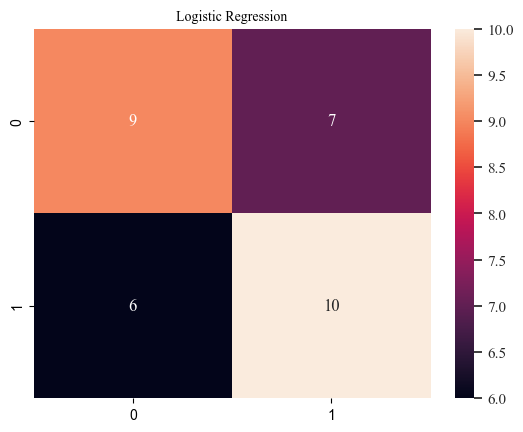

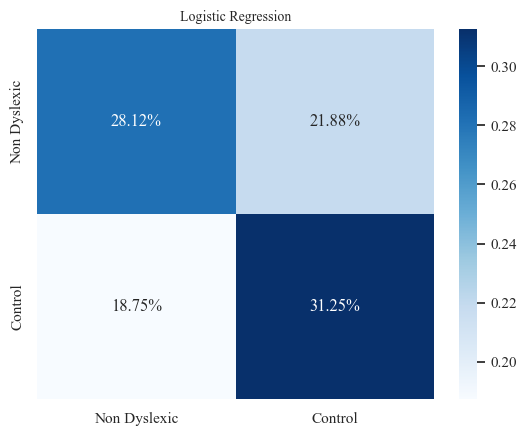

In [15]:
##### Logistic regression model

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train the logistic regression model
clf = LogisticRegression()
clf.fit(X_train_scaled, y_train)

# Make predictions on training data and testing data
y_train_pred = clf.predict(X_train_scaled)
y_test_pred = clf.predict(X_test_scaled)

# Calculate training and testing accuracy
train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

# Print both accuracies
print(f"Training Accuracy on Inferior Frontal Gyrus- pars triangularis (Logistic Regression): {train_accuracy * 100:.2f}%")
print(f"Testing Accuracy on Inferior Frontal Gyrus- pars triangularis (Logistic Regression): {test_accuracy * 100:.2f}%")

# Optionally, print classification report for testing data
print("\nClassification Report for Testing Data on Inferior Frontal Gyrus- pars triangularis (Logistic Regression):")
print(classification_report(y_test, y_test_pred))

cm = confusion_matrix(y_test, y_test_pred)
print(cm)
plt.title('Logistic Regression (Inferior Frontal Gyrus- pars triangularis)', fontsize = 10, fontname="Times New Roman") # title with fontsize 10
sns.set(font="Times New Roman")
sns.heatmap(cm, annot=True)
#plt.savefig("../../Figure_Output/1-Inferior_Frontal_Gyrus/Inferior_Frontal_Gyrus_ROI_1(Log_Reg)_simple.png", dpi=600)
plt.show() 
plt.title('Logistic Regression (Inferior Frontal Gyrus- pars triangularis)', fontsize = 10, fontname="Times New Roman") # title with fontsize 10
sns.set(font="Times New Roman")
sns.heatmap(cm/np.sum(cm,axis=1), annot=True, xticklabels=['Non Dyslexic','Control'], yticklabels=['Non Dyslexic','Control'], fmt='.2%', cmap='Blues')
#plt.savefig("../../Figure-Output/1-Inferior_Frontal_Gyrus/Inferior_Frontal_Gyrus_ROI_1(Log_Reg)_percent.png", dpi=600)
plt.show()

In [40]:
###### SVM model
# from sklearn.svm import SVC
# from sklearn.preprocessing import StandardScaler
# from sklearn.metrics import accuracy_score, classification_report
# from sklearn.model_selection import train_test_split
# from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
# import seaborn as sns

# 1. Standardize the feature matrix
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 2. Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# 3. Train the SVM model
svm_clf = SVC(kernel='rbf', C=1, gamma='scale', random_state=42)
svm_clf.fit(X_train, y_train)

# 4. Make predictions on both training and testing sets
y_train_pred = svm_clf.predict(X_train)
y_test_pred = svm_clf.predict(X_test)

# 5. Evaluate the model
train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

# Print training and testing accuracy
print(f"Training Accuracy on Inferior Frontal Gyrus- pars triangularis (Support Vector Machine): {train_accuracy * 100:.2f}%")
print(f"Testing Accuracy on Inferior Frontal Gyrus- pars triangularis (Support Vector Machine): {test_accuracy * 100:.2f}%")

# Print classification report for testing data
print("\nClassification Report for Testing Data on Inferior Frontal Gyrus- pars triangularis (Support Vector Machine):")
print(classification_report(y_test, y_test_pred))

cm = confusion_matrix(y_test, y_test_pred)
print(cm)
plt.title('Support Vector Machine (Inferior Frontal Gyrus- pars triangularis)', fontsize = 10, fontname="Times New Roman") # title with fontsize 10
sns.set(font="Times New Roman")
sns.heatmap(cm, annot=True)
#plt.savefig("../../Figure_Output/1-Inferior_Frontal_Gyrus/Inferior_Frontal_Gyrus_ROI_1(SVM)_simple.png", dpi=600)
plt.show() 
plt.title('Support Vector Machine (Inferior Frontal Gyrus- pars triangularis)', fontsize = 10, fontname="Times New Roman") # title with fontsize 10
sns.set(font="Times New Roman")
sns.heatmap(cm/np.sum(cm,axis=1), annot=True, xticklabels=['Non Dyslexic','Control'], yticklabels=['Non Dyslexic','Control'], fmt='.2%', cmap='Blues')
#plt.savefig("../../Figure-Output/1-Inferior_Frontal_Gyrus/Inferior_Frontal_Gyrus_ROI_1(SVM)_percent.png", dpi=600)
plt.show()

Training Accuracy: 73.44%
Testing Accuracy: 65.62%

Classification Report for Testing Data:
              precision    recall  f1-score   support

           0       0.65      0.69      0.67        16
           1       0.67      0.62      0.65        16

    accuracy                           0.66        32
   macro avg       0.66      0.66      0.66        32
weighted avg       0.66      0.66      0.66        32



In [41]:
##### KNN model
# from sklearn.model_selection import train_test_split
# from sklearn.preprocessing import StandardScaler
# from sklearn.neighbors import KNeighborsClassifier
# from sklearn.metrics import accuracy_score, classification_report
# from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
# import seaborn as sns

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train the KNN model
knn = KNeighborsClassifier(n_neighbors=5)  # You can adjust 'n_neighbors' as needed
knn.fit(X_train_scaled, y_train)

# Make predictions on training data and testing data
y_train_pred = knn.predict(X_train_scaled)
y_test_pred = knn.predict(X_test_scaled)

# Calculate training and testing accuracy
train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

# Print training and testing accuracy
print(f"Training Accuracy on Inferior Frontal Gyrus- pars triangularis (k-nearest neighbors): {train_accuracy * 100:.2f}%")
print(f"Testing Accuracy on Inferior Frontal Gyrus- pars triangularis (k-nearest neighbors): {test_accuracy * 100:.2f}%")

# Print classification report for testing data
print("\nClassification Report for Testing Data on Inferior Frontal Gyrus- pars triangularis (k-nearest neighbors):")
print(classification_report(y_test, y_test_pred))

cm = confusion_matrix(y_test, y_test_pred)
print(cm)
plt.title('k-nearest neighbors (Inferior Frontal Gyrus- pars triangularis)', fontsize = 10, fontname="Times New Roman") # title with fontsize 10
sns.set(font="Times New Roman")
sns.heatmap(cm, annot=True)
#plt.savefig("../../Figure_Output/1-Inferior_Frontal_Gyrus/Inferior_Frontal_Gyrus_ROI_1(KNN)_simple.png", dpi=600)
plt.show() 
plt.title('k-nearest neighbors (Inferior Frontal Gyrus- pars triangularis)', fontsize = 10, fontname="Times New Roman") # title with fontsize 10
sns.set(font="Times New Roman")
sns.heatmap(cm/np.sum(cm,axis=1), annot=True, xticklabels=['Non Dyslexic','Control'], yticklabels=['Non Dyslexic','Control'], fmt='.2%', cmap='Blues')
#plt.savefig("../../Figure_Output/1-Inferior_Frontal_Gyrus/Inferior_Frontal_Gyrus_ROI_1(KNN)_percent.png", dpi=600)
plt.show()

Training Accuracy: 69.53%
Testing Accuracy: 56.25%

Classification Report for Testing Data:
              precision    recall  f1-score   support

           0       0.55      0.75      0.63        16
           1       0.60      0.38      0.46        16

    accuracy                           0.56        32
   macro avg       0.57      0.56      0.55        32
weighted avg       0.57      0.56      0.55        32



In [45]:
###### ANN Model
# from sklearn.model_selection import train_test_split
# from sklearn.preprocessing import StandardScaler
# from sklearn.neighbors import KNeighborsClassifier
# from sklearn.metrics import accuracy_score, classification_report
# from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
# import keras
# from keras.models import Sequential
# from keras.layers import Dense
# import seaborn as sns
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Total Training set:- ","Dataset:-", X_train_scaled.shape,"Label:-",y_train.shape)
print("Total Testing set:- ","Dataset:-",X_test_scaled.shape,"Label:-",y_test.shape)
#print(X_train_scaled.shape[1])
# define the input shape
input_shape = (X_train_scaled.shape[1],)
# define the model architecture
model = Sequential()
model.add(Dense(128, activation='relu', input_shape=input_shape))
model.add(Dense(64, activation='relu'))
model.add(Dense(32, activation='relu'))
model.add(Dense(1, activation='sigmoid'))
# compile the model
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
# print the model summary
model.summary()
# train the model
model.fit(X_train_scaled, y_train, batch_size=64, epochs=50)

y_train_pred = model.predict(X_train_scaled)
y_train_pred = np.where(y_train_pred > 0.70, 1, 0)
y_test_pred = model.predict(X_test_scaled)
y_test_pred = np.where(y_test_pred > 0.70, 1, 0)
# Calculate training and testing accuracy
# display(y_test_pred[:10])
# display(y_test[:10])
train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

# Print training and testing accuracy
print(f"Training Accuracy on Inferior Frontal Gyrus- pars triangularis (Artificial Neural Network): {train_accuracy * 100:.2f}%")
print(f"Testing Accuracy on Inferior Frontal Gyrus- pars triangularis (Artificial Neural Network): {test_accuracy * 100:.2f}%")

# Print classification report for testing data
print("\nClassification Report for Testing Data on Inferior Frontal Gyrus- pars triangularis (Artificial Neural Network):")
print(classification_report(y_test, y_test_pred))

cm = confusion_matrix(y_test, y_test_pred)
print(cm)
plt.title('Artificial Neural Network (Inferior Frontal Gyrus- pars triangularis)', fontsize = 10, fontname="Times New Roman") # title with fontsize 10
sns.set(font="Times New Roman")
sns.heatmap(cm, annot=True)
#plt.savefig("../../Figure_Output/1-Inferior_Frontal_Gyrus/Inferior_Frontal_Gyrus_ROI_1(ANN)_simple.png", dpi=600)
plt.show() 
plt.title('Artificial Neural Network (Inferior Frontal Gyrus- pars triangularis)', fontsize = 10, fontname="Times New Roman") # title with fontsize 10
sns.set(font="Times New Roman")
sns.heatmap(cm/np.sum(cm,axis=1), annot=True, xticklabels=['Non Dyslexic','Control'], yticklabels=['Non Dyslexic','Control'], fmt='.2%', cmap='Blues')
#plt.savefig("../../Figure_Output/1-Inferior_Frontal_Gyrus/Inferior_Frontal_Gyrus_ROI_1(ANN)_percent.png", dpi=600)
plt.show()

Total Training set:-  Dataset:- (128, 2377) Label:- (128,)
Total Testing set:-  Dataset:- (32, 2377) Label:- (32,)


D:\Aanaconda3\envs\env_sih\lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_21"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_84 (Dense)                     │ (None, 128)                 │         304,384 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_85 (Dense)                     │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_86 (Dense)                     │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_87 (Dense)                     │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 314,753 (1.20 MB)

 Trainable params: 314,753 (1.20 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.4844 - loss: 0.7551
Epoch 2/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.8333 - loss: 0.4796
Epoch 3/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.9010 - loss: 0.4136
Epoch 4/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.9583 - loss: 0.3683
Epoch 5/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.9844 - loss: 0.3379
Epoch 6/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.9740 - loss: 0.3157
Epoch 7/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.9792 - loss: 0.3022
Epoch 8/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.9844 - loss: 0.2663
Epoch 9/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.9896 - loss: 0.2284
Epoch 10/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.9948 - loss: 0.2117
Epoch 11/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.9896 - loss: 0.1786
Epoch 12/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.9948 - loss: 0.1356
E

array([[8, 8],
       [7, 9]])

## Loading a single ROI **(MEAN)**:- 2. Inferior Frontal Gyrus- pars opercularis
#### Then performing the experiments.

In [46]:
####Loading the saved dataset in np format.
cmd2 = np.load("../../Data_Mask-ROI/1-Inferior_Frontal_Gyrus/control_mean_pars_opercularis.npz")
ndmd2 = np.load("../../Data_Mask-ROI/1-Inferior_Frontal_Gyrus/non_dyslexic_mean_pars_opercularis.npz")
control_mean_data2 = cmd2["control_mean_data2"]
non_dyslexic_mean_data2=ndmd2["non_dyslexic_mean_data2"]
####
print(len(control_mean_data2))
print(len(non_dyslexic_mean_data2))
print(control_mean_data2[0].shape)
print(non_dyslexic_mean_data2[0].shape)

# Combine the aggregated data from both groups
X = np.vstack([control_mean_data2, non_dyslexic_mean_data2])  # Shape: (n_samples, n_voxels)
y = np.array([1] * len(control_mean_data2) + [0] * len(non_dyslexic_mean_data2))  # Binary labels

print(X.shape)
print(y.shape)

80
80
(3846,)
(3846,)
(160, 3846)
(160,)


Training Accuracy: 100.00%
Testing Accuracy: 50.00%

Classification Report for Testing Data:
              precision    recall  f1-score   support

           0       0.50      0.47      0.48        32
           1       0.50      0.53      0.52        32

    accuracy                           0.50        64
   macro avg       0.50      0.50      0.50        64
weighted avg       0.50      0.50      0.50        64

[[15 17]
 [15 17]]


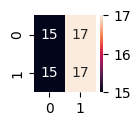

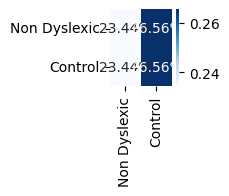

In [89]:
##### Logistic regression model
# from sklearn.model_selection import train_test_split
# from sklearn.linear_model import LogisticRegression
# from sklearn.preprocessing import StandardScaler
# from sklearn.metrics import accuracy_score, classification_report
# from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
# import seaborn as sns

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train the logistic regression model
clf = LogisticRegression()
clf.fit(X_train_scaled, y_train)

# Make predictions on training data and testing data
y_train_pred = clf.predict(X_train_scaled)
y_test_pred = clf.predict(X_test_scaled)

# Calculate training and testing accuracy
train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

# Print training and testing accuracy
print(f"Training Accuracy on Inferior Frontal Gyrus- pars opercularis (Logistic regression): {train_accuracy * 100:.2f}%")
print(f"Testing Accuracy on Inferior Frontal Gyrus- pars opercularis (Logistic regression): {test_accuracy * 100:.2f}%")

# Print classification report for testing data
print("\nClassification Report for Testing Data on Inferior Frontal Gyrus- pars opercularis (Logistic regression):")
print(classification_report(y_test, y_test_pred))

cm = confusion_matrix(y_test, y_test_pred)
print(cm)
plt.title('Logistic regression (Inferior Frontal Gyrus- pars opercularis)', fontsize = 10, fontname="Times New Roman") # title with fontsize 10
sns.set(font="Times New Roman")
sns.heatmap(cm, annot=True)
#plt.savefig("../../Figure_Output/1-Inferior_Frontal_Gyrus/Inferior_Frontal_Gyrus_ROI_2(log_reg)_simple.png", dpi=600)
plt.show() 
plt.title('Logistic regression (Inferior Frontal Gyrus- pars opercularis)', fontsize = 10, fontname="Times New Roman") # title with fontsize 10
sns.set(font="Times New Roman")
sns.heatmap(cm/np.sum(cm,axis=1), annot=True, xticklabels=['Non Dyslexic','Control'], yticklabels=['Non Dyslexic','Control'], fmt='.2%', cmap='Blues')
#plt.savefig("../../Figure_Output/1-Inferior_Frontal_Gyrus/Inferior_Frontal_Gyrus_ROI_2(log_reg)_percent.png", dpi=600)
plt.show()

In [49]:
##### SVM model
# from sklearn.svm import SVC
# from sklearn.preprocessing import StandardScaler
# from sklearn.metrics import accuracy_score, classification_report
# from sklearn.model_selection import train_test_split
# from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
# import seaborn as sns

# 1. Standardize the feature matrix
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 2. Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# 3. Train the SVM model
svm_clf = SVC(kernel='rbf', C=1, gamma='scale', random_state=42)
svm_clf.fit(X_train, y_train)

# 4. Make predictions on both training and testing sets
y_train_pred = svm_clf.predict(X_train)
y_test_pred = svm_clf.predict(X_test)

# 5. Evaluate the model
train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

# Print training and testing accuracy
print(f"Training Accuracy on Inferior Frontal Gyrus- pars opercularis (Support Vector Machine): {train_accuracy * 100:.2f}%")
print(f"Testing Accuracy on Inferior Frontal Gyrus- pars opercularis (Support Vector Machine): {test_accuracy * 100:.2f}%")

# Print classification report for testing data
print("\nClassification Report for Testing Data on Inferior Frontal Gyrus- pars opercularis (Support Vector Machine):")
print(classification_report(y_test, y_test_pred))

cm = confusion_matrix(y_test, y_test_pred)
print(cm)
plt.title('Support Vector Machine (Inferior Frontal Gyrus- pars opercularis)', fontsize = 10, fontname="Times New Roman") # title with fontsize 10
sns.set(font="Times New Roman")
sns.heatmap(cm, annot=True)
#plt.savefig("../../Figure_Output/1-Inferior_Frontal_Gyrus/Inferior_Frontal_Gyrus_ROI_2(SVM)_simple.png", dpi=600)
plt.show() 
plt.title('Support Vector Machine (Inferior Frontal Gyrus- pars opercularis)', fontsize = 10, fontname="Times New Roman") # title with fontsize 10
sns.set(font="Times New Roman")
sns.heatmap(cm/np.sum(cm,axis=1), annot=True, xticklabels=['Non Dyslexic','Control'], yticklabels=['Non Dyslexic','Control'], fmt='.2%', cmap='Blues')
#plt.savefig("../../Figure-Output/1-Inferior_Frontal_Gyrus/Inferior_Frontal_Gyrus_ROI_2(SVM)_percent.png", dpi=600)
plt.show()

Training Accuracy: 73.44%
Testing Accuracy: 65.62%

Classification Report for Testing Data:
              precision    recall  f1-score   support

           0       0.63      0.75      0.69        16
           1       0.69      0.56      0.62        16

    accuracy                           0.66        32
   macro avg       0.66      0.66      0.65        32
weighted avg       0.66      0.66      0.65        32



In [50]:
##### KNN model
# from sklearn.model_selection import train_test_split
# from sklearn.preprocessing import StandardScaler
# from sklearn.neighbors import KNeighborsClassifier
# from sklearn.metrics import accuracy_score, classification_report
# from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
# import seaborn as sns

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train the KNN model
knn = KNeighborsClassifier(n_neighbors=5)  # You can adjust 'n_neighbors' as needed
knn.fit(X_train_scaled, y_train)

# Make predictions on training data and testing data
y_train_pred = knn.predict(X_train_scaled)
y_test_pred = knn.predict(X_test_scaled)

# Calculate training and testing accuracy
train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

# Print training and testing accuracy
print(f"Training Accuracy on Inferior Frontal Gyrus- pars opercularis (k-nearest neighbors): {train_accuracy * 100:.2f}%")
print(f"Testing Accuracy on Inferior Frontal Gyrus- pars opercularis (k-nearest neighbors): {test_accuracy * 100:.2f}%")

# Print classification report for testing data
print("\nClassification Report for Testing Data on Inferior Frontal Gyrus- pars opercularis (k-nearest neighbors):")
print(classification_report(y_test, y_test_pred))

cm = confusion_matrix(y_test, y_test_pred)
print(cm)
plt.title('k-nearest neighbors (Inferior Frontal Gyrus- pars opercularis)', fontsize = 10, fontname="Times New Roman") # title with fontsize 10
sns.set(font="Times New Roman")
sns.heatmap(cm, annot=True)
#plt.savefig("../../Figure_Output/1-Inferior_Frontal_Gyrus/Inferior_Frontal_Gyrus_ROI_2(KNN)_simple.png", dpi=600)
plt.show() 
plt.title('k-nearest neighbors (Inferior Frontal Gyrus- pars opercularis)', fontsize = 10, fontname="Times New Roman") # title with fontsize 10
sns.set(font="Times New Roman")
sns.heatmap(cm/np.sum(cm,axis=1), annot=True, xticklabels=['Non Dyslexic','Control'], yticklabels=['Non Dyslexic','Control'], fmt='.2%', cmap='Blues')
#plt.savefig("../../Figure_Output/1-Inferior_Frontal_Gyrus/Inferior_Frontal_Gyrus_ROI_2(KNN)_percent.png", dpi=600)
plt.show()

Training Accuracy: 54.69%
Testing Accuracy: 46.88%

Classification Report for Testing Data:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        16
           1       0.48      0.94      0.64        16

    accuracy                           0.47        32
   macro avg       0.24      0.47      0.32        32
weighted avg       0.24      0.47      0.32        32



Total Training set:-  Dataset:- (256, 3846) Label:- (256,)
Total Testing set:-  Dataset:- (64, 3846) Label:- (64,)


D:\Aanaconda3\envs\env_sih\lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_56"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_224 (Dense)                    │ (None, 128)                 │         492,416 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_225 (Dense)                    │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_226 (Dense)                    │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_227 (Dense)                    │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 502,785 (1.92 MB)

 Trainable params: 502,785 (1.92 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - accuracy: 0.4740 - loss: 0.7393
Epoch 2/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.8375 - loss: 0.4295
Epoch 3/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.9021 - loss: 0.3762
Epoch 4/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.9120 - loss: 0.3171
Epoch 5/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.9453 - loss: 0.2844
Epoch 6/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.9604 - loss: 0.2665
Epoch 7/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.9833 - loss: 0.2028
Epoch 8/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.9901 - loss: 0.1542
Epoch 9/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.9911 - loss: 0.1162
Epoch 10/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.9901 - loss: 0.0766
Epoch 11/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.9969 - loss: 0.0386
Epoch 12/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.9927 - loss: 0.0266
E

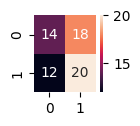

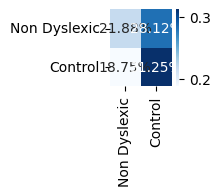

In [88]:
###### ANN Model
# from sklearn.model_selection import train_test_split
# from sklearn.preprocessing import StandardScaler
# from sklearn.neighbors import KNeighborsClassifier
# from sklearn.metrics import accuracy_score, classification_report
# from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
# import keras
# from keras.models import Sequential
# from keras.layers import Dense
# import seaborn as sns
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Total Training set:- ","Dataset:-", X_train_scaled.shape,"Label:-",y_train.shape)
print("Total Testing set:- ","Dataset:-",X_test_scaled.shape,"Label:-",y_test.shape)
#print(X_train_scaled.shape[1])
# define the input shape
input_shape = (X_train_scaled.shape[1],)
# define the model architecture
model = Sequential()
model.add(Dense(128, activation='relu', input_shape=input_shape))
model.add(Dense(64, activation='relu'))
model.add(Dense(32, activation='relu'))
model.add(Dense(1, activation='sigmoid'))
# compile the model
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
# print the model summary
model.summary()
# train the model
model.fit(X_train_scaled, y_train, batch_size=64, epochs=50)

y_train_pred = model.predict(X_train_scaled)
y_train_pred = np.where(y_train_pred > 0.70, 1, 0)
y_test_pred = model.predict(X_test_scaled)
y_test_pred = np.where(y_test_pred > 0.70, 1, 0)
# Calculate training and testing accuracy
# display(y_test_pred[:10])
# display(y_test[:10])
train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

# Print training and testing accuracy
print(f"Training Accuracy on Inferior Frontal Gyrus- pars opercularis (Artificial Neural Network): {train_accuracy * 100:.2f}%")
print(f"Testing Accuracy on Inferior Frontal Gyrus- pars opercularis (Artificial Neural Network): {test_accuracy * 100:.2f}%")

# Print classification report for testing data
print("\nClassification Report for Testing Data on Inferior Frontal Gyrus- pars opercularis (Artificial Neural Network):")
print(classification_report(y_test, y_test_pred))

cm = confusion_matrix(y_test, y_test_pred)
print(cm)
plt.title('Artificial Neural Network (Inferior Frontal Gyrus- pars opercularis)', fontsize = 10, fontname="Times New Roman") # title with fontsize 10
sns.set(font="Times New Roman")
sns.heatmap(cm, annot=True)
#plt.savefig("../../Figure_Output/1-Inferior_Frontal_Gyrus/Inferior_Frontal_Gyrus_ROI_2(ANN)_simple.png", dpi=600)
plt.show() 
plt.title('Artificial Neural Network (Inferior Frontal Gyrus- pars opercularis)', fontsize = 10, fontname="Times New Roman") # title with fontsize 10
sns.set(font="Times New Roman")
sns.heatmap(cm/np.sum(cm,axis=1), annot=True, xticklabels=['Non Dyslexic','Control'], yticklabels=['Non Dyslexic','Control'], fmt='.2%', cmap='Blues')
#plt.savefig("../../Figure_Output/1-Inferior_Frontal_Gyrus/Inferior_Frontal_Gyrus_ROI_2(ANN)_percent.png", dpi=600)
plt.show()

## Combining all the ROIs **(MEAN)**:- Inferior Frontal Gyrus- 1) pars triangularis & 2) pars opercularis.
#### Combining them into a single dataset to perform the experiments.

In [37]:
####Loading the saved dataset in np format.
cmd1 = np.load("../../Data_Mask-ROI/1-Inferior_Frontal_Gyrus/control_mean_pars_triangularis.npz")
ndmd1 = np.load("../../Data_Mask-ROI/1-Inferior_Frontal_Gyrus/non_dyslexic_mean_pars_triangularis.npz")
control_mean_data1 = cmd1["control_mean_data1"]
non_dyslexic_mean_data1=ndmd1["non_dyslexic_mean_data1"]
cmd2 = np.load("../../Data_Mask-ROI/1-Inferior_Frontal_Gyrus/control_mean_pars_opercularis.npz")
ndmd2 = np.load("../../Data_Mask-ROI/1-Inferior_Frontal_Gyrus/non_dyslexic_mean_pars_opercularis.npz")
control_mean_data2 = cmd2["control_mean_data2"]
non_dyslexic_mean_data2=ndmd2["non_dyslexic_mean_data2"]
####
print(len(control_mean_data1))
print(len(non_dyslexic_mean_data1))
print(len(control_mean_data2))
print(len(non_dyslexic_mean_data2))
print(control_mean_data1[0].shape)
print(non_dyslexic_mean_data1[0].shape)
print(control_mean_data2[0].shape)
print(non_dyslexic_mean_data2[0].shape)
#print(control_mean_data1[79][2376])
print()
####Bringing the data to equal shape and size
control_m_d1=[]
non_dyslexic_m_d1=[]
for i in range(len(control_mean_data1)):
    #control_mean_data1[i]=np.resize(control_mean_data1[i], (control_mean_data2[0].shape[0], ))
    #control_m_d1.insert(i, np.pad(control_mean_data1[i], (0, control_mean_data2[0].shape[0]-control_mean_data1[0].shape[0]), 'constant'))
    control_m_d1.insert(i, np.pad(control_mean_data1[i], (0, control_mean_data2[0].shape[0]-control_mean_data1[0].shape[0]), 'mean'))
    #control_m_d1.insert(i, np.resize(control_mean_data1[i], (control_mean_data2[0].shape[0], )))
for i in range(len(non_dyslexic_mean_data1)):
    #non_dyslexic_mean_data1[i]=np.resize(non_dyslexic_mean_data1[i], (non_dyslexic_mean_data2[0].shape[0], ))
    #non_dyslexic_m_d1.insert(i, np.pad(non_dyslexic_mean_data1[i], (0, non_dyslexic_mean_data2[0].shape[0]-non_dyslexic_mean_data1[0].shape[0]), 'constant'))
    non_dyslexic_m_d1.insert(i, np.pad(non_dyslexic_mean_data1[i], (0, non_dyslexic_mean_data2[0].shape[0]-non_dyslexic_mean_data1[0].shape[0]), 'mean'))
    #non_dyslexic_m_d1.insert(i, np.resize(non_dyslexic_mean_data1[i], (non_dyslexic_mean_data2[0].shape[0], )))
print(control_m_d1[0].shape)
print(non_dyslexic_m_d1[0].shape)
print(control_mean_data2[0].shape)
print(non_dyslexic_mean_data2[0].shape)


80
80
80
80
(2377,)
(2377,)
(3846,)
(3846,)

(3846,)
(3846,)
(3846,)
(3846,)


In [ ]:
##TESTING TESTING##
##NO NEED TO RUN THIS##
##TESTING TESTING##
t1=np.array([15, 6, 32])
t2=np.array([5, 7, 4])
t3=np.array([915, 54, 77])
t4=np.array([8, 160, 27])
t=[t1,t2,t3,t4]
print(len(t))
print(t[0].shape[0])
print(t[3][2])
N = 4
s=[]
# t[0]=np.resize(t[0], (7, ))
#t[0]=np.resize(t[0], (7, ))
# print(t[0].shape)
# print(t[1].shape)
# print(t[0])
for i in range(len(t)):
    #s.append(np.resize(t[i], (7, )))
    #t[i]=np.resize(t[i], (7, ))
    #t[i].resize((7, ), refcheck=False)
    #t[i]=np.pad(t[i], (0, N), 'constant')
    #s.insert(i, np.pad(t[i], (0, N), 'constant'))
    s.insert(i,np.resize(t[i], (7, )))
    
print(t) 
print(s)

ll1=len(control_m_d1)+len(control_mean_data2)
ll2=len(non_dyslexic_m_d1)+len(non_dyslexic_mean_data2)
yyyy = np.array([1] * ll1 + [0] * ll2)  # Binary labels
print(yyyy.shape)
print(yyyy)
yy1=np.zeros((yyyy.size, yyyy.max() + 1))
yy1[np.arange(yyyy.size), yyyy] = 1
print(yy1.shape)
print(yy1)

In [53]:
# Combine the aggregated data from both groups
ll1=len(control_m_d1)+len(control_mean_data2)
ll2=len(non_dyslexic_m_d1)+len(non_dyslexic_mean_data2)
X = np.vstack([control_m_d1,control_mean_data2, non_dyslexic_m_d1,non_dyslexic_mean_data2])  # Shape: (n_samples, n_voxels)
y = np.array([1] * ll1 + [0] * ll2)  # Binary labels
print(X.shape)
print(y.shape)
##############################################################################################
##################### "If you want to save the Resultant Dataset" ############################
#np.savez("Data_Mask-Mean/Inferior_Frontal_Gyrus_Mean_Combine.npz", X=X, y=y)
##################### "If you want to save the Resultant Dataset" ############################
##############################################################################################

(320, 3846)
(320,)


In [8]:
# from sklearn.model_selection import train_test_split
# from sklearn.linear_model import LogisticRegression
# from sklearn.preprocessing import StandardScaler
# from sklearn.metrics import accuracy_score, classification_report
# from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
# import seaborn as sns

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train the logistic regression model
clf = LogisticRegression()
clf.fit(X_train_scaled, y_train)

# Make predictions on training data and testing data
y_train_pred = clf.predict(X_train_scaled)
y_test_pred = clf.predict(X_test_scaled)

# Calculate training and testing accuracy
train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

# Print training and testing accuracy
print(f"Training Accuracy on Inferior Frontal Gyrus- pars triangularis & pars opercularis (Logistic regression): {train_accuracy * 100:.2f}%")
print(f"Testing Accuracy on Inferior Frontal Gyrus- pars triangularis & pars opercularis (Logistic regression): {test_accuracy * 100:.2f}%")

# Print classification report for testing data
print("\nClassification Report for Testing Data on Inferior Frontal Gyrus- pars triangularis & pars opercularis (Logistic regression):")
print(classification_report(y_test, y_test_pred))

cm = confusion_matrix(y_test, y_test_pred)
print(cm)
plt.title('Logistic regression (Inferior Frontal Gyrus- pars triangularis & pars opercularis)', fontsize = 10, fontname="Times New Roman") # title with fontsize 10
sns.set(font="Times New Roman")
sns.heatmap(cm, annot=True)
#plt.savefig("../../Figure_Output/1-Inferior_Frontal_Gyrus/Inferior_Frontal_Gyrus_All_ROIs(log_reg)_simple.png", dpi=600)
plt.show() 
plt.title('Logistic regression (Inferior Frontal Gyrus- pars triangularis & pars opercularis)', fontsize = 10, fontname="Times New Roman") # title with fontsize 10
sns.set(font="Times New Roman")
sns.heatmap(cm/np.sum(cm,axis=1), annot=True, xticklabels=['Non Dyslexic','Control'], yticklabels=['Non Dyslexic','Control'], fmt='.2%', cmap='Blues')
#plt.savefig("../../Figure_Output/1-Inferior_Frontal_Gyrus/Inferior_Frontal_Gyrus_All_ROIs(log_reg)_percent.png", dpi=600)
plt.show()

Training Accuracy: 100.00%
Testing Accuracy: 50.00%

Classification Report for Testing Data:
              precision    recall  f1-score   support

           0       0.50      0.47      0.48        32
           1       0.50      0.53      0.52        32

    accuracy                           0.50        64
   macro avg       0.50      0.50      0.50        64
weighted avg       0.50      0.50      0.50        64



In [9]:
# from sklearn.svm import SVC
# from sklearn.preprocessing import StandardScaler
# from sklearn.metrics import accuracy_score, classification_report
# from sklearn.model_selection import train_test_split
# from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
# import seaborn as sns

# 1. Standardize the feature matrix
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 2. Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# 3. Train the SVM model
svm_clf = SVC(kernel='rbf', C=1, gamma='scale', random_state=42)
svm_clf.fit(X_train, y_train)

# 4. Make predictions on both training and testing sets
y_train_pred = svm_clf.predict(X_train)
y_test_pred = svm_clf.predict(X_test)

# 5. Evaluate the model
train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

# Print training and testing accuracy
print(f"Training Accuracy on Inferior Frontal Gyrus- pars triangularis & pars opercularis (Support Vector Machine): {train_accuracy * 100:.2f}%")
print(f"Testing Accuracy on Inferior Frontal Gyrus- pars triangularis & pars opercularis (Support Vector Machine): {test_accuracy * 100:.2f}%")

# Print classification report for testing data
print("\nClassification Report for Testing Data on Inferior Frontal Gyrus- pars triangularis & pars opercularis (Support Vector Machine):")
print(classification_report(y_test, y_test_pred))

cm = confusion_matrix(y_test, y_test_pred)
print(cm)
plt.title('Support Vector Machine (Inferior Frontal Gyrus- pars triangularis & pars opercularis)', fontsize = 10, fontname="Times New Roman") # title with fontsize 10
sns.set(font="Times New Roman")
sns.heatmap(cm, annot=True)
#plt.savefig("../../Figure_Output/1-Inferior_Frontal_Gyrus/Inferior_Frontal_Gyrus_All_ROIs(svm)_simple.png", dpi=600)
plt.show() 
plt.title('Support Vector Machine (Inferior Frontal Gyrus- pars triangularis & pars opercularis)', fontsize = 10, fontname="Times New Roman") # title with fontsize 10
sns.set(font="Times New Roman")
sns.heatmap(cm/np.sum(cm,axis=1), annot=True, xticklabels=['Non Dyslexic','Control'], yticklabels=['Non Dyslexic','Control'], fmt='.2%', cmap='Blues')
#plt.savefig("../../Figure_Output/1-nferior_Frontal_Gyrus/Inferior_Frontal_Gyrus_All_ROIs(svm)_percent.png", dpi=600)
plt.show()

Training Accuracy: 74.61%
Testing Accuracy: 53.12%

Classification Report for Testing Data:
              precision    recall  f1-score   support

           0       0.52      0.72      0.61        32
           1       0.55      0.34      0.42        32

    accuracy                           0.53        64
   macro avg       0.54      0.53      0.51        64
weighted avg       0.54      0.53      0.51        64



In [10]:
# from sklearn.model_selection import train_test_split
# from sklearn.preprocessing import StandardScaler
# from sklearn.neighbors import KNeighborsClassifier
# from sklearn.metrics import accuracy_score, classification_report
# from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
# import seaborn as sns

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train the KNN model
knn = KNeighborsClassifier(n_neighbors=5)  # You can adjust 'n_neighbors' as needed
knn.fit(X_train_scaled, y_train)

# Make predictions on training data and testing data
y_train_pred = knn.predict(X_train_scaled)
y_test_pred = knn.predict(X_test_scaled)

# Calculate training and testing accuracy
train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

# Print training and testing accuracy
print(f"Training Accuracy on Inferior Frontal Gyrus- pars triangularis & pars opercularis (k-nearest neighbors): {train_accuracy * 100:.2f}%")
print(f"Testing Accuracy on Inferior Frontal Gyrus- pars triangularis & pars opercularis (k-nearest neighbors): {test_accuracy * 100:.2f}%")

# Print classification report for testing data
print("\nClassification Report for Testing Data on Inferior Frontal Gyrus- pars triangularis & pars opercularis (k-nearest neighbors):")
print(classification_report(y_test, y_test_pred))

cm = confusion_matrix(y_test, y_test_pred)
print(cm)
plt.title('k-nearest neighbors (Inferior Frontal Gyrus- pars triangularis & pars opercularis)', fontsize = 10, fontname="Times New Roman") # title with fontsize 10
sns.set(font="Times New Roman")
sns.heatmap(cm, annot=True)
#plt.savefig("../../Figure_Output/1-Inferior_Frontal_Gyrus/Inferior_Frontal_Gyrus_All_ROIs(KNN)_simple.png", dpi=600)
plt.show() 
plt.title('k-nearest neighbors (Inferior Frontal Gyrus- pars triangularis & pars opercularis)', fontsize = 10, fontname="Times New Roman") # title with fontsize 10
sns.set(font="Times New Roman")
sns.heatmap(cm/np.sum(cm,axis=1), annot=True, xticklabels=['Non Dyslexic','Control'], yticklabels=['Non Dyslexic','Control'], fmt='.2%', cmap='Blues')
#plt.savefig("../../Figure_Output/1-Inferior_Frontal_Gyrus/Inferior_Frontal_Gyrus_All_ROIs(KNN)_percent.png", dpi=600)
plt.show()

Training Accuracy: 59.77%
Testing Accuracy: 45.31%

Classification Report for Testing Data:
              precision    recall  f1-score   support

           0       0.38      0.16      0.22        32
           1       0.47      0.75      0.58        32

    accuracy                           0.45        64
   macro avg       0.43      0.45      0.40        64
weighted avg       0.43      0.45      0.40        64



In [16]:
# from sklearn.model_selection import train_test_split
# from sklearn.preprocessing import StandardScaler
# from sklearn.neighbors import KNeighborsClassifier
# from sklearn.metrics import accuracy_score, classification_report
# from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
# import seaborn as sns

ll1=len(control_m_d1)+len(control_mean_data2)
ll2=len(non_dyslexic_m_d1)+len(non_dyslexic_mean_data2)
X = np.vstack([control_m_d1,control_mean_data2, non_dyslexic_m_d1,non_dyslexic_mean_data2])  # Shape: (n_samples, n_voxels)
y = np.array([1] * ll1 + [0] * ll2)  # Binary labels
# yyyy = np.array([1] * ll1 + [0] * ll2)  # Binary labels
# y=np.zeros((yyyy.size, yyyy.max() + 1))
# y[np.arange(yyyy.size), yyyy] = 1
print("Total Dataset:- ",X.shape)
print("Total Labels:- ",y.shape)

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Total Training set:- ","Dataset:-", X_train_scaled.shape,"Label:-",y_train.shape)
print("Total Testing set:- ","Dataset:-",X_test_scaled.shape,"Label:-",y_test.shape)
#print(X_train_scaled.shape[1])


Total Dataset:-  (320, 3846)
Total Labels:-  (320,)
Total Training set:-  Dataset:- (256, 3846) Label:- (256,)
Total Testing set:-  Dataset:- (64, 3846) Label:- (64,)


In [31]:
# import keras
# from keras.models import Sequential
# from keras.layers import Dense
# define the input shape
input_shape = (X_train_scaled.shape[1],)
# define the model architecture
model = Sequential()
model.add(Dense(128, activation='relu', input_shape=input_shape))
model.add(Dense(64, activation='relu'))
model.add(Dense(32, activation='relu'))
model.add(Dense(1, activation='sigmoid'))
# compile the model
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
# print the model summary
model.summary()
# train the model
model.fit(X_train_scaled, y_train, batch_size=64, epochs=50)

y_train_pred = model.predict(X_train_scaled)
y_train_pred = np.where(y_train_pred > 0.70, 1, 0)
y_test_pred = model.predict(X_test_scaled)
y_test_pred = np.where(y_test_pred > 0.70, 1, 0)
# Calculate training and testing accuracy
# display(y_test_pred[:10])
# display(y_test[:10])
train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

# Print training and testing accuracy
print(f"Training Accuracy on Inferior Frontal Gyrus- pars triangularis & pars opercularis (Artificial Neural Network): {train_accuracy * 100:.2f}%")
print(f"Testing Accuracy on Inferior Frontal Gyrus- pars triangularis & pars opercularis (Artificial Neural Network): {test_accuracy * 100:.2f}%")

# Print classification report for testing data
print("\nClassification Report for Testing Data on Inferior Frontal Gyrus- pars triangularis & pars opercularis (Artificial Neural Network):")
print(classification_report(y_test, y_test_pred))

cm = confusion_matrix(y_test, y_test_pred)
print(cm)
plt.title('Artificial Neural Network (Inferior Frontal Gyrus- pars triangularis & pars opercularis)', fontsize = 10, fontname="Times New Roman") # title with fontsize 10
sns.set(font="Times New Roman")
sns.heatmap(cm, annot=True)
#plt.savefig("../../Figure_Output/1-Inferior_Frontal_Gyrus/Inferior_Frontal_Gyrus_All_ROIs(ANN)_simple.png", dpi=600)
plt.show() 
plt.title('Artificial Neural Network (Inferior Frontal Gyrus- pars triangularis & pars opercularis)', fontsize = 10, fontname="Times New Roman") # title with fontsize 10
sns.set(font="Times New Roman")
sns.heatmap(cm/np.sum(cm,axis=1), annot=True, xticklabels=['Non Dyslexic','Control'], yticklabels=['Non Dyslexic','Control'], fmt='.2%', cmap='Blues')
#plt.savefig("../../Figure_Output/1-Inferior_Frontal_Gyrus/Inferior_Frontal_Gyrus_All_ROIs(ANN)_percent.png", dpi=600)
plt.show()

D:\Aanaconda3\envs\env_sih\lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_17"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_68 (Dense)                     │ (None, 128)                 │         492,416 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_69 (Dense)                     │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_70 (Dense)                     │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_71 (Dense)                     │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 502,785 (1.92 MB)

 Trainable params: 502,785 (1.92 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.4906 - loss: 0.7918 
Epoch 2/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8224 - loss: 0.4261
Epoch 3/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8760 - loss: 0.3773
Epoch 4/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8922 - loss: 0.3521
Epoch 5/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9490 - loss: 0.3170
Epoch 6/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9557 - loss: 0.2731
Epoch 7/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9828 - loss: 0.2265
Epoch 8/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9755 - loss: 0.1819
Epoch 9/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9896 - loss: 0.1536
Epoch 10/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9917 - loss: 0.1115
Epoch 11/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9927 - loss: 0.0898
Epoch 12/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9943 - loss: 0.0542


array([[ 9, 23],
       [ 6, 26]])

#### <b> Display results in dataframe tabular format</b>

In [4]:
import pandas as pd
import numpy as np
df = pd.DataFrame(np.random.randn(8,5),
                   pd.MultiIndex.from_product([['Logistic Regression', 'Support Vector Machine','k-nearest neighbors','Artificial Neural Networks'], ['Non-Dyslexic', 'Control']]),
                   columns=['Accuracy','roc_auc','Precision','Recall','f1-score'])
#df=df.style.set_sticky(axis="index")
df=df.style.set_table_styles([{'selector': 'table','props': [("font-family" , 'Times New Roman'),("border", "1px solid #eee")]}], [{'selector': 'tr','props': [("font-family" , 'Times New Roman'),("border", "1px solid #eee")]}])
display(df)
#df.to_excel('../../Figure_Output/1-Inferior_Frontal_Gyrus/Table_Mean_ROIs_Inferior_Frontal_Gyrus.xlsx', engine='openpyxl')


In [15]:
##!pip install openpyxl

In [12]:
import pandas as pd
import numpy as np

arrays = [["bar", "bar", "baz", "baz", "foo", "foo", "qux", "qux"],
          ["one", "two", "one", "two", "one", "two", "one", "two"]]
 
tuples = list(zip(*arrays))
# [('bar', 'one'), ('bar', 'two'), ('baz', 'one'), ('baz', 'two'), 
# ('foo', 'one'), ('foo', 'two'), ('qux', 'one'), ('qux', 'two')]

index = pd.MultiIndex.from_tuples(tuples, names=["first", "second"])

s = pd.Series(np.random.randn(8), index=index)

display(s)
#s.to_excel('text.xlsx', merge_cells=True)

first  second
bar    one       0.815093
       two      -0.364536
baz    one       1.017394
       two      -0.280902
foo    one       1.053540
       two       0.493656
qux    one       0.164811
       two       0.610805
dtype: float64